In [32]:
from sqlalchemy import create_engine, URL
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report


In [5]:
# connecting to lendiq database
# engine = create_engine('postgresql://postgres:Syzygy009@@localhost:5432/lendiq') # password is causing an issue
connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="Syzygy009@",
    host="127.0.0.1",
    port=5432,
    database="lendiq"
)

In [6]:
engine = create_engine(connection_url)

In [8]:
pd.read_sql("SELECT table_schema, table_name FROM information_schema.tables WHERE table_name = 'loans'", engine)

,table_schema,table_name
0,public,loans


In [9]:
query = """
SELECT
    l.loan_amnt, l.grade, l.int_rate, l.purpose,
    EXTRACT(year FROM l.issue_d) AS issue_year,
    b.annual_inc, b.emp_length,
    CASE WHEN b.emp_length IS NULL THEN 1 ELSE 0 END AS emp_length_missing,
    cp.dti,
    CASE
        WHEN l.loan_status IN ('Charged Off', 'Default', 'Late (31-120 days)') THEN 1
        WHEN l.loan_status = 'Fully Paid' THEN 0
        ELSE NULL
    END AS target
FROM public.loans l
LEFT JOIN public.borrowers b ON l.loan_id = b.loan_id
LEFT JOIN public.credit_profile cp ON l.loan_id = cp.loan_id
"""

df = pd.read_sql(query, engine)
df = df.dropna(subset=['target'])

print(df.shape)
print(df['target'].value_counts())

(1325535, 10)
target
0.0    1041952
1.0     283583
Name: count, dtype: int64


In [11]:
df.head()

,loan_amnt,grade,int_rate,purpose,issue_year,annual_inc,emp_length,emp_length_missing,dti,target
0,15000,B,10.99,debt_consolidation,2014.0,150000.00,10.0,0,35.93,0.0
1,6050,D,15.61,home_improvement,2014.0,25000.00,5.0,0,24.82,0.0
2,10000,C,12.99,debt_consolidation,2014.0,65632.06,3.0,0,23.24,0.0
3,18000,B,10.15,debt_consolidation,2014.0,110000.00,0.0,0,22.62,0.0
4,10000,E,19.52,credit_card,2014.0,51600.00,10.0,0,39.91,0.0


In [13]:
df.dtypes

loan_amnt               int64
grade                     str
int_rate              float64
purpose                   str
issue_year            float64
annual_inc            float64
emp_length            float64
emp_length_missing      int64
dti                   float64
target                float64
dtype: object

In [14]:
df.isnull().sum()

loan_amnt                 0
grade                     0
int_rate                  0
purpose                   0
issue_year                0
annual_inc                0
emp_length            77391
emp_length_missing        0
dti                     340
target                    0
dtype: int64

In [16]:
# Fill nulls
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())
df['dti'] = df['dti'].fillna(df['dti'].median())

# Encode categoricals
df['grade'] = df['grade'].astype('category')
df['purpose'] = df['purpose'].astype('category')

# Fix target type
df['target'] = df['target'].astype(int)

In [17]:
print(df.isnull().sum())
print(df.dtypes)

loan_amnt             0
grade                 0
int_rate              0
purpose               0
issue_year            0
annual_inc            0
emp_length            0
emp_length_missing    0
dti                   0
target                0
dtype: int64
loan_amnt                int64
grade                 category
int_rate               float64
purpose               category
issue_year             float64
annual_inc             float64
emp_length             float64
emp_length_missing       int64
dti                    float64
target                   int64
dtype: object


### Dataset Split

In [25]:
X = df.drop(columns='target')
y = df['target']

# First split off 15% for test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Then split remaining into 70% train / 15% val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (928404, 9)
Val:   (198300, 9)
Test:  (198831, 9)


I chose LightGBM for its speed on large tabular datasets and native categorical support, with early stopping to prevent overfitting and class weight adjustment for the imbalanced target

n_estimators=500 — starting point, early stopping will find the optimal number anyway so the exact value doesn't matter much

learning_rate=0.05 — standard starting point, lower than default (0.1) which generally gives better generalisation

num_leaves=31 — LightGBM default, reasonable complexity for a first run

scale_pos_weight — mathematically justified by your class ratio (78/22). Without it the model would be biased toward predicting 0 since that's the majority class

early_stopping(50) — prevents overfitting by stopping when validation AUC plateaus

In [27]:
import lightgbm as lgb

In [28]:
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

[LightGBM] [Info] Number of positive: 198621, number of negative: 729783
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1061
[LightGBM] [Info] Number of data points in the train set: 928404, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.213938 -> initscore=-1.301349
[LightGBM] [Info] Start training from score -1.301349
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[5]	valid_0's binary_logloss: 0.507245


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [29]:
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

[LightGBM] [Info] Number of positive: 198621, number of negative: 729783
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004887 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1061
[LightGBM] [Info] Number of data points in the train set: 928404, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.213938 -> initscore=-1.301349
[LightGBM] [Info] Start training from score -1.301349
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[5]	valid_0's auc: 0.704256	valid_0's binary_logloss: 0.507245


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [30]:
cat_features = ['grade', 'purpose']

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

[LightGBM] [Info] Number of positive: 198621, number of negative: 729783
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003891 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1061
[LightGBM] [Info] Number of data points in the train set: 928404, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.213938 -> initscore=-1.301349
[LightGBM] [Info] Start training from score -1.301349
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[5]	valid_0's auc: 0.704256	valid_0's binary_logloss: 0.507245


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [31]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=127,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

[LightGBM] [Info] Number of positive: 198621, number of negative: 729783
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003789 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1061
[LightGBM] [Info] Number of data points in the train set: 928404, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.213938 -> initscore=-1.301349
[LightGBM] [Info] Start training from score -1.301349
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.710268	valid_0's binary_logloss: 0.512626
Early stopping, best iteration is:
[25]	valid_0's auc: 0.709366	valid_0's binary_logloss: 0.506337


,boosting_type,'gbdt'
,num_leaves,127
,max_depth,-1
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [33]:
# Evaluate on test set
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test AUC: {auc:.4f}")
print(classification_report(y_test, y_pred))

Test AUC: 0.7099
              precision    recall  f1-score   support

           0       0.79      1.00      0.88    156293
           1       0.00      0.00      0.00     42538

    accuracy                           0.79    198831
   macro avg       0.39      0.50      0.44    198831
weighted avg       0.62      0.79      0.69    198831



c:\Users\sajja\anaconda3\envs\sql_loan\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sajja\anaconda3\envs\sql_loan\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sajja\anaconda3\envs\sql_loan\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [35]:
from sklearn.metrics import roc_auc_score, classification_report

# Use 0.3 threshold instead of default 0.5
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_pred_proba >= 0.3).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test AUC: {auc:.4f}\n")
print(classification_report(y_test, y_pred_adjusted))

Test AUC: 0.7099

              precision    recall  f1-score   support

           0       0.84      0.81      0.83    156293
           1       0.40      0.45      0.42     42538

    accuracy                           0.74    198831
   macro avg       0.62      0.63      0.63    198831
weighted avg       0.75      0.74      0.74    198831



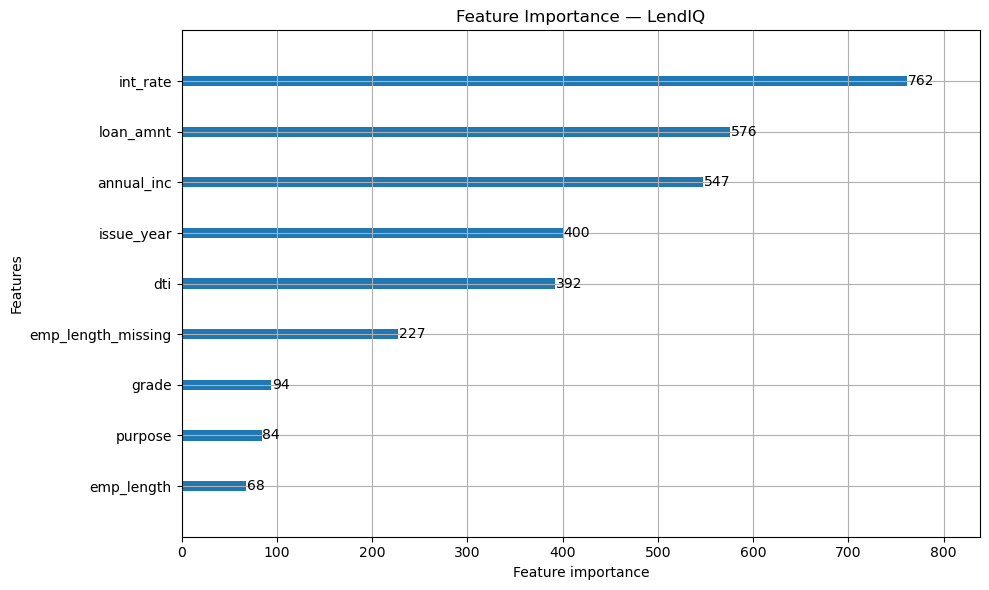

In [34]:
import matplotlib.pyplot as plt

lgb.plot_importance(model, figsize=(10, 6), title='Feature Importance — LendIQ')
plt.tight_layout()
plt.show()